# Pembacaan 2 File Polar H10 TXT — Ground Truth HR 3 Menit Terakhir

Notebook ini membaca **dua file `.txt` Polar H10** untuk dua subjek.

Versi ini sudah diperbarui agar nilai ground truth HR dihitung dari **3 menit terakhir sebelum tombol stop**.  
Artinya, jika file Polar lebih panjang dari 180 detik, data yang dipakai adalah:

\[
t_{start} = t_{akhir} - 180\ detik
\]

\[
t_{end} = t_{akhir}
\]

Pendekatan ini cocok jika perekaman Polar sudah berjalan lebih dulu, lalu tombol stop Polar ditekan setelah atau bersamaan dengan stop radar.

In [1]:
# ============================================================
# 1. INPUT FILE POLAR H10
# Isi path file Polar H10 untuk dua subjek
# ============================================================

POLAR_TXT_OBJECT_1 = r"D:\DATASET PENULISAN BUKU TA\PEMBACAAN POLAR H10 (SUBJECT 1)/Polar H10 - 5_11 - 17.52.txt"
POLAR_TXT_OBJECT_2 = r"D:\DATASET PENULISAN BUKU TA\PEMBACAAN POLAR H10 (SUBJECT 2)/Polar H10 - 5_11 - 17.52.txt"

NAMA_OBJECT_1 = "Object 1"
NAMA_OBJECT_2 = "Object 2"

# ============================================================
# DURASI GROUND TRUTH YANG DIAMBIL
# Karena data radar direkam 3 menit, maka Polar juga dipotong 180 detik.
# Mode yang digunakan: 180 detik terakhir sebelum stop.
# ============================================================

TARGET_DURATION_S = 180

# Opsional manual:
# Isi None dulu.
# Jika auto-detect tetap salah/gagal, isi nama kolom HR dan waktu sesuai output "DAFTAR KOLOM".
HR_COLUMN_OBJECT_1 = None
HR_COLUMN_OBJECT_2 = None
TIME_COLUMN_OBJECT_1 = None
TIME_COLUMN_OBJECT_2 = None

# Jika file Polar hanya berisi daftar angka HR tanpa timestamp,
# asumsi interval data HR adalah 1 detik per baris.
FALLBACK_SAMPLE_INTERVAL_S = 1.0


In [2]:
# ============================================================
# 2. IMPORT LIBRARY
# ============================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)


In [3]:
# ============================================================
# 3. FUNGSI DASAR
# ============================================================

def read_text_lines(file_path):
    """
    Membaca file txt sebagai list baris.
    Mendukung beberapa encoding umum Windows/UTF.
    """
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan:\n{file_path}")

    encodings = ["utf-8-sig", "utf-8", "latin1", "cp1252"]
    last_error = None

    for enc in encodings:
        try:
            with open(file_path, "r", encoding=enc, errors="replace") as f:
                return f.readlines()
        except Exception as e:
            last_error = e

    raise ValueError(f"Gagal membaca file {file_path}. Error terakhir: {last_error}")


def preview_file(file_path, n=20):
    """
    Menampilkan preview baris awal file.
    """
    lines = read_text_lines(file_path)
    print(f"\nPREVIEW FILE: {file_path}")
    print("=" * 90)
    for i, line in enumerate(lines[:n], 1):
        print(f"{i:02d}: {line.rstrip()}")
    print("=" * 90)


def to_numeric_clean(series):
    """
    Mengubah data ke numerik.
    Mendukung koma desimal dan membersihkan karakter non-angka.
    """
    s = series.astype(str).str.strip()
    s = s.str.replace(",", ".", regex=False)
    s = s.str.replace(r"[^\d\.\-\+eE]", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


def normalize_col_name(x):
    return str(x).strip().lower().replace(" ", "").replace("_", "").replace("-", "")


def is_hr_like(values):
    """
    Mengecek apakah data numerik masuk akal sebagai HR manusia.
    """
    v = pd.Series(values).dropna()
    if len(v) < 3:
        return False

    median_val = v.median()
    min_val = v.min()
    max_val = v.max()

    return (30 <= median_val <= 220) and (25 <= min_val <= 230) and (max_val <= 250)


def safe_datetime_parse(series):
    """
    Parsing datetime dengan aman.
    """
    try:
        dt = pd.to_datetime(series, errors="coerce")
        return dt
    except Exception:
        return pd.Series([pd.NaT] * len(series), index=series.index)


def make_index_time(n, sample_interval_s=1.0):
    """
    Membuat waktu dari index.
    """
    return pd.Series(np.arange(n, dtype=float) * sample_interval_s)


In [4]:
# ============================================================
# 4. FUNGSI PARSING TABEL
# ============================================================

def score_dataframe(df):
    """
    Memberi skor dataframe berdasarkan kemungkinan memuat HR.
    """
    if df is None or df.empty:
        return -999

    score = 0
    cols = list(df.columns)
    col_text = " ".join([str(c).lower() for c in cols])

    if any(k in col_text for k in ["hr", "heart", "bpm", "heartrate"]):
        score += 20
    if any(k in col_text for k in ["time", "timestamp", "date", "waktu"]):
        score += 10

    score += min(df.shape[1], 6)
    score += min(len(df) / 10, 20)

    for col in cols:
        x = to_numeric_clean(df[col])
        if is_hr_like(x):
            score += 20

    return score


def read_table_auto(file_path, max_skip_scan=120):
    """
    Mencoba membaca file sebagai tabel dengan beberapa separator dan skiprows.
    """
    file_path = Path(file_path)
    lines = read_text_lines(file_path)

    encodings = ["utf-8-sig", "utf-8", "latin1", "cp1252"]
    seps = [None, "\t", ";", ",", r"\s+"]

    best_df = None
    best_info = None
    best_score = -999

    max_scan = min(max_skip_scan, len(lines))

    for skiprows in range(max_scan):
        line = lines[skiprows].strip().lower()

        # Setelah 20 baris, hanya coba jika baris tampak seperti header.
        if skiprows > 20:
            if not any(k in line for k in ["hr", "heart", "bpm", "time", "timestamp", "date", "waktu"]):
                continue

        for enc in encodings:
            for sep in seps:
                try:
                    df = pd.read_csv(
                        file_path,
                        sep=sep,
                        engine="python",
                        encoding=enc,
                        skiprows=skiprows
                    )

                    df = df.dropna(axis=1, how="all")
                    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed", case=False, regex=True)]

                    if df.empty:
                        continue

                    score = score_dataframe(df)

                    if score > best_score:
                        best_df = df
                        best_info = {"skiprows": skiprows, "separator": sep, "encoding": enc, "score": score}
                        best_score = score

                except Exception:
                    pass

    return best_df, best_info


def detect_hr_column(df, manual_col=None):
    """
    Deteksi kolom HR dari tabel.
    """
    if manual_col is not None:
        if manual_col not in df.columns:
            raise ValueError(f"Kolom HR manual '{manual_col}' tidak ditemukan. Kolom tersedia: {list(df.columns)}")
        return manual_col

    cols = list(df.columns)

    # Berdasarkan nama kolom
    for col in cols:
        c = normalize_col_name(col)
        is_hr_name = ("hr" in c or "heart" in c or "bpm" in c or "heartrate" in c)
        not_rr_interval = ("rr" not in c and "interval" not in c)
        if is_hr_name and not_rr_interval:
            x = to_numeric_clean(df[col])
            if is_hr_like(x):
                return col

    # Berdasarkan nilai numerik
    candidates = []
    for col in cols:
        x = to_numeric_clean(df[col])
        if is_hr_like(x):
            valid = x.dropna()
            candidates.append((col, len(valid), valid.std()))

    if candidates:
        # Pilih yang valid terbanyak
        candidates = sorted(candidates, key=lambda z: z[1], reverse=True)
        return candidates[0][0]

    return None


def detect_time_column(df, hr_col, manual_col=None):
    """
    Deteksi kolom waktu/timestamp.
    """
    if manual_col is not None:
        if manual_col not in df.columns:
            raise ValueError(f"Kolom waktu manual '{manual_col}' tidak ditemukan. Kolom tersedia: {list(df.columns)}")
        return manual_col

    cols = [c for c in df.columns if c != hr_col]

    # Prioritas nama kolom waktu
    for col in cols:
        c = normalize_col_name(col)
        if any(k in c for k in ["timestamp", "time", "date", "waktu"]):
            return col

    # Prioritas kolom datetime string
    for col in cols:
        dt = safe_datetime_parse(df[col].astype(str))
        if dt.notna().mean() > 0.5:
            return col

    # Prioritas kolom numeric meningkat
    for col in cols:
        x = to_numeric_clean(df[col]).dropna()
        if len(x) >= 3:
            diffs = np.diff(x.values[:min(50, len(x))])
            if np.mean(diffs >= 0) > 0.7:
                return col

    return None


def parse_time_from_column(df, time_col, n, fallback_interval_s=1.0):
    """
    Membuat kolom Timestamp dan Time_s.
    Jika time_col None, gunakan index.
    """
    if time_col is None:
        time_s = make_index_time(n, fallback_interval_s)
        timestamp = time_s.astype(str)
        return timestamp.reset_index(drop=True), time_s.reset_index(drop=True), "index_as_time"

    s = df[time_col].astype(str).reset_index(drop=True)

    # Coba datetime
    dt = safe_datetime_parse(s)
    if dt.notna().mean() > 0.5:
        first_valid = dt.dropna().iloc[0]
        time_s = (dt - first_valid).dt.total_seconds()
        return s, time_s.reset_index(drop=True), time_col

    # Coba numeric
    num = to_numeric_clean(s).reset_index(drop=True)
    valid = num.dropna()

    if len(valid) >= 3:
        median_val = valid.median()
        max_val = valid.max()

        if median_val > 1e17:
            dt = pd.to_datetime(num, unit="ns", errors="coerce")
            time_s = (dt - dt.dropna().iloc[0]).dt.total_seconds()
        elif median_val > 1e14:
            dt = pd.to_datetime(num, unit="us", errors="coerce")
            time_s = (dt - dt.dropna().iloc[0]).dt.total_seconds()
        elif median_val > 1e11:
            dt = pd.to_datetime(num, unit="ms", errors="coerce")
            time_s = (dt - dt.dropna().iloc[0]).dt.total_seconds()
        elif median_val > 1e8:
            dt = pd.to_datetime(num, unit="s", errors="coerce")
            time_s = (dt - dt.dropna().iloc[0]).dt.total_seconds()
        else:
            # elapsed time biasa
            if max_val > 10000:
                time_s = num / 1000.0
            else:
                time_s = num

        return s, pd.Series(time_s).reset_index(drop=True), time_col

    # fallback
    time_s = make_index_time(n, fallback_interval_s)
    timestamp = time_s.astype(str)
    return timestamp.reset_index(drop=True), time_s.reset_index(drop=True), "index_as_time"


In [5]:
# ============================================================
# 5. FALLBACK DAN FUNGSI BACA POLAR HR
# ============================================================

def extract_hr_from_text_lines(file_path, sample_interval_s=1.0):
    """
    Fallback untuk file TXT Polar yang tidak berbentuk tabel.
    Cara kerja:
    - Ambil semua angka dari setiap baris.
    - Pilih angka yang berada dalam rentang HR manusia 30-220 bpm.
    - Buat Time_s dari index dengan interval default 1 detik.
    """
    lines = read_text_lines(file_path)

    values = []
    source_lines = []

    for i, line in enumerate(lines, 1):
        nums = re.findall(r"[-+]?\d+(?:[.,]\d+)?", line)

        hr_candidates = []
        for n in nums:
            try:
                val = float(n.replace(",", "."))
                if 30 <= val <= 220:
                    hr_candidates.append(val)
            except Exception:
                pass

        # Jika satu baris punya banyak angka, pilih angka terakhir yang masuk rentang HR.
        # Ini sering aman untuk format "timestamp HR".
        if hr_candidates:
            values.append(hr_candidates[-1])
            source_lines.append(i)

    if len(values) < 3:
        raise ValueError("Fallback ekstraksi angka gagal. Tidak cukup angka HR dalam rentang 30-220 bpm.")

    df = pd.DataFrame({
        "Timestamp": [str(t) for t in np.arange(len(values)) * sample_interval_s],
        "Time_s": np.arange(len(values), dtype=float) * sample_interval_s,
        "HR_bpm": values,
        "Source_Line": source_lines
    })

    return df


def read_polar_hr(file_path, subject_name, manual_hr_col=None, manual_time_col=None, show_preview=True):
    """
    Fungsi utama pembacaan Polar:
    1. Coba baca sebagai tabel.
    2. Jika kolom HR tidak ditemukan, fallback ekstraksi angka.
    """
    if show_preview:
        preview_file(file_path, n=15)

    df_raw, info = read_table_auto(file_path)

    print(f"\nHASIL PARSING TABEL: {subject_name}")
    print("=" * 90)

    used_method = "table"

    if df_raw is not None:
        print("Info parsing:", info)
        print("Daftar kolom:", list(df_raw.columns))
        display(df_raw.head(10))

        hr_col = detect_hr_column(df_raw, manual_hr_col)

        if hr_col is not None:
            time_col = detect_time_column(df_raw, hr_col, manual_time_col)

            hr = to_numeric_clean(df_raw[hr_col]).reset_index(drop=True)
            timestamp, time_s, used_time_col = parse_time_from_column(
                df_raw.reset_index(drop=True),
                time_col,
                n=len(df_raw),
                fallback_interval_s=FALLBACK_SAMPLE_INTERVAL_S
            )

            df = pd.DataFrame({
                "Subject": subject_name,
                "Timestamp": timestamp.astype(str),
                "Time_s": time_s,
                "HR_bpm": hr
            })

            df = df.dropna(subset=["HR_bpm"]).reset_index(drop=True)

            if len(df) >= 3:
                df["Time_s"] = df["Time_s"] - df["Time_s"].iloc[0]
                if df["Time_s"].isna().any():
                    df["Time_s"] = make_index_time(len(df), FALLBACK_SAMPLE_INTERVAL_S)

                print("\nKOLOM TERPILIH")
                print("Kolom HR   :", hr_col)
                print("Kolom waktu:", used_time_col)
                print("Metode     :", used_method)
                print("Jumlah data full:", len(df))
                print("Durasi full     :", round(df["Time_s"].max() - df["Time_s"].min(), 2), "detik")

                return df, df_raw, hr_col, used_time_col, info, used_method

        print("\nKolom HR tidak ditemukan dari tabel. Mencoba fallback ekstraksi angka dari TXT...")

    else:
        print("File tidak berhasil diparse sebagai tabel. Mencoba fallback ekstraksi angka dari TXT...")

    # Fallback
    used_method = "regex_fallback"
    df_fb = extract_hr_from_text_lines(file_path, FALLBACK_SAMPLE_INTERVAL_S)
    df_fb.insert(0, "Subject", subject_name)

    print("\nFALLBACK BERHASIL")
    print("Metode     :", used_method)
    print("Jumlah data full:", len(df_fb))
    print("Durasi full     :", round(df_fb["Time_s"].max() - df_fb["Time_s"].min(), 2), "detik")
    display(df_fb.head(10))

    return df_fb[["Subject", "Timestamp", "Time_s", "HR_bpm"]], df_raw, "regex_hr_value", "index_as_time", info, used_method


In [6]:
# ============================================================
# 6. FUNGSI CUT 3 MENIT TERAKHIR SEBELUM STOP
# ============================================================

def cut_last_seconds(df, target_duration_s=180):
    """
    Mengambil data terakhir sepanjang target_duration_s.
    Ini digunakan untuk menyamakan ground truth dengan durasi radar 3 menit.

    Contoh:
    Jika data Polar berdurasi 297 detik, maka yang dipakai adalah:
    117 detik sampai 297 detik.
    """
    df = df.copy().reset_index(drop=True)

    end_time_s = df["Time_s"].max()
    start_time_s = max(df["Time_s"].min(), end_time_s - target_duration_s)

    df_cut = df[
        (df["Time_s"] >= start_time_s) &
        (df["Time_s"] <= end_time_s)
    ].copy().reset_index(drop=True)

    # Time_cut_s dibuat dari 0 agar grafik 3 menit terakhir mudah dibaca.
    df_cut["Time_cut_s"] = df_cut["Time_s"] - df_cut["Time_s"].iloc[0]

    return df_cut, start_time_s, end_time_s


def summarize_hr_full_and_last(df_full, df_cut, subject_name):
    """
    Ringkasan HR full recording dan 3 menit terakhir.
    Nilai ground truth utama adalah HR Mean Last180_bpm.
    """
    full_duration_s = df_full["Time_s"].max() - df_full["Time_s"].min()
    cut_duration_s = df_cut["Time_s"].max() - df_cut["Time_s"].min()

    return {
        "Subject": subject_name,

        "Full Timestamp Awal": df_full["Timestamp"].iloc[0],
        "Full Timestamp Akhir": df_full["Timestamp"].iloc[-1],
        "Full Durasi_s": round(full_duration_s, 2),
        "Full Jumlah Data": len(df_full),
        "Full HR Mean_bpm": round(df_full["HR_bpm"].mean(), 2),

        "Cut Timestamp Awal": df_cut["Timestamp"].iloc[0],
        "Cut Timestamp Akhir": df_cut["Timestamp"].iloc[-1],
        "Cut Durasi_s": round(cut_duration_s, 2),
        "Cut Jumlah Data": len(df_cut),
        "HR Mean Last180_bpm": round(df_cut["HR_bpm"].mean(), 2),
        "HR Median Last180_bpm": round(df_cut["HR_bpm"].median(), 2),
        "HR Min Last180_bpm": round(df_cut["HR_bpm"].min(), 2),
        "HR Max Last180_bpm": round(df_cut["HR_bpm"].max(), 2),
        "HR Std Last180_bpm": round(df_cut["HR_bpm"].std(), 2),
    }


In [7]:
# ============================================================
# 7. BACA DUA FILE POLAR H10
# ============================================================

df_obj1_full, raw_obj1, hr_col_1, time_col_1, info_1, method_1 = read_polar_hr(
    POLAR_TXT_OBJECT_1,
    NAMA_OBJECT_1,
    manual_hr_col=HR_COLUMN_OBJECT_1,
    manual_time_col=TIME_COLUMN_OBJECT_1,
    show_preview=True
)

df_obj2_full, raw_obj2, hr_col_2, time_col_2, info_2, method_2 = read_polar_hr(
    POLAR_TXT_OBJECT_2,
    NAMA_OBJECT_2,
    manual_hr_col=HR_COLUMN_OBJECT_2,
    manual_time_col=TIME_COLUMN_OBJECT_2,
    show_preview=True
)

# ============================================================
# CUT 3 MENIT TERAKHIR SEBELUM STOP
# ============================================================

df_obj1_cut, obj1_start_s, obj1_end_s = cut_last_seconds(df_obj1_full, TARGET_DURATION_S)
df_obj2_cut, obj2_start_s, obj2_end_s = cut_last_seconds(df_obj2_full, TARGET_DURATION_S)

summary_df = pd.DataFrame([
    summarize_hr_full_and_last(df_obj1_full, df_obj1_cut, NAMA_OBJECT_1),
    summarize_hr_full_and_last(df_obj2_full, df_obj2_cut, NAMA_OBJECT_2),
])

print("\n" + "=" * 90)
print("RINGKASAN HR POLAR H10")
print("Ground truth utama = HR Mean Last180_bpm")
print("=" * 90)
display(summary_df)

print("\nRentang data yang dipakai:")
print(f"{NAMA_OBJECT_1}: {obj1_start_s:.2f} s sampai {obj1_end_s:.2f} s")
print(f"{NAMA_OBJECT_2}: {obj2_start_s:.2f} s sampai {obj2_end_s:.2f} s")



PREVIEW FILE: D:\DATASET PENULISAN BUKU TA\PEMBACAAN POLAR H10 (SUBJECT 1)/Polar H10 - 5_11 - 17.52.txt
01: Phone timestamp;HR [bpm];HRV [ms];Breathing interval [rpm];
02: 2026-05-11T17:52:48.563;85
03: 2026-05-11T17:52:49.609;83
04: 2026-05-11T17:52:50.569;82;11.7
05: 2026-05-11T17:52:51.616;81;10.5
06: 2026-05-11T17:52:52.578;84;40.7
07: 2026-05-11T17:52:53.627;85;38.0
08: 2026-05-11T17:52:54.558;87;34.0
09: 2026-05-11T17:52:55.580;89;31.4
10: 2026-05-11T17:52:56.598;90;30.3
11: 2026-05-11T17:52:57.558;92;30.1
12: 2026-05-11T17:52:58.580;93;29.1
13: 2026-05-11T17:52:59.620;96;27.8
14: 2026-05-11T17:53:00.560;96;50.7
15: 2026-05-11T17:53:01.579;96;49.3

HASIL PARSING TABEL: Object 1
Info parsing: {'skiprows': 0, 'separator': None, 'encoding': 'utf-8-sig', 'score': 73}
Daftar kolom: ['Phone timestamp', 'HR [bpm]', 'HRV [ms]']


,Phone timestamp,HR [bpm],HRV [ms]
0,2026-05-11T17:52:48.563,85,NaN
1,2026-05-11T17:52:49.609,83,NaN
2,2026-05-11T17:52:50.569,82,11.7
3,2026-05-11T17:52:51.616,81,10.5
4,2026-05-11T17:52:52.578,84,40.7
5,2026-05-11T17:52:53.627,85,38.0
6,2026-05-11T17:52:54.558,87,34.0
7,2026-05-11T17:52:55.580,89,31.4
8,2026-05-11T17:52:56.598,90,30.3
9,2026-05-11T17:52:57.558,92,30.1



KOLOM TERPILIH
Kolom HR   : HR [bpm]
Kolom waktu: Phone timestamp
Metode     : table
Jumlah data full: 232
Durasi full     : 231.0 detik

PREVIEW FILE: D:\DATASET PENULISAN BUKU TA\PEMBACAAN POLAR H10 (SUBJECT 2)/Polar H10 - 5_11 - 17.52.txt
01: Phone timestamp;HR [bpm];HRV [ms];Breathing interval [rpm];
02: 2026-05-11T17:52:40.037;84
03: 2026-05-11T17:52:41.026;84
04: 2026-05-11T17:52:42.017;84
05: 2026-05-11T17:52:43.040;83;29.7
06: 2026-05-11T17:52:44.028;82;26.6
07: 2026-05-11T17:52:45.019;81;23.5
08: 2026-05-11T17:52:46.039;81;22.9
09: 2026-05-11T17:52:47.027;81;21.6
10: 2026-05-11T17:52:48.020;81;19.8
11: 2026-05-11T17:52:49.043;82;19.0
12: 2026-05-11T17:52:50.034;82;18.3
13: 2026-05-11T17:52:51.019;82;17.3
14: 2026-05-11T17:52:52.044;82;17.5
15: 2026-05-11T17:52:53.028;82;16.5

HASIL PARSING TABEL: Object 2
Info parsing: {'skiprows': 0, 'separator': None, 'encoding': 'utf-8-sig', 'score': 73}
Daftar kolom: ['Phone timestamp', 'HR [bpm]', 'HRV [ms]']


,Phone timestamp,HR [bpm],HRV [ms]
0,2026-05-11T17:52:40.037,84,NaN
1,2026-05-11T17:52:41.026,84,NaN
2,2026-05-11T17:52:42.017,84,NaN
3,2026-05-11T17:52:43.040,83,29.7
4,2026-05-11T17:52:44.028,82,26.6
5,2026-05-11T17:52:45.019,81,23.5
6,2026-05-11T17:52:46.039,81,22.9
7,2026-05-11T17:52:47.027,81,21.6
8,2026-05-11T17:52:48.020,81,19.8
9,2026-05-11T17:52:49.043,82,19.0



KOLOM TERPILIH
Kolom HR   : HR [bpm]
Kolom waktu: Phone timestamp
Metode     : table
Jumlah data full: 239
Durasi full     : 238.0 detik

RINGKASAN HR POLAR H10
Ground truth utama = HR Mean Last180_bpm


,Subject,Full Timestamp Awal,Full Timestamp Akhir,Full Durasi_s,Full Jumlah Data,Full HR Mean_bpm,Cut Timestamp Awal,Cut Timestamp Akhir,Cut Durasi_s,Cut Jumlah Data,HR Mean Last180_bpm,HR Median Last180_bpm,HR Min Last180_bpm,HR Max Last180_bpm,HR Std Last180_bpm
0,Object 1,2026-05-11T17:52:48.563,2026-05-11T17:56:39.562,231.0,232,91.5,2026-05-11T17:53:39.562,2026-05-11T17:56:39.562,180.00,181,92.30,94.0,82,102,5.33
1,Object 2,2026-05-11T17:52:40.037,2026-05-11T17:56:38.042,238.0,239,81.6,2026-05-11T17:53:38.067,2026-05-11T17:56:38.042,179.98,181,79.16,78.0,74,93,3.66



Rentang data yang dipakai:
Object 1: 51.00 s sampai 231.00 s
Object 2: 58.00 s sampai 238.00 s


In [8]:
# ============================================================
# 8. TAMPILKAN TIMESTAMP DAN HR 3 MENIT TERAKHIR
# ============================================================

print("10 DATA AWAL CUT OBJECT 1")
display(df_obj1_cut[["Timestamp", "Time_s", "Time_cut_s", "HR_bpm"]].head(10))

print("10 DATA AWAL CUT OBJECT 2")
display(df_obj2_cut[["Timestamp", "Time_s", "Time_cut_s", "HR_bpm"]].head(10))

print("10 DATA AKHIR CUT OBJECT 1")
display(df_obj1_cut[["Timestamp", "Time_s", "Time_cut_s", "HR_bpm"]].tail(10))

print("10 DATA AKHIR CUT OBJECT 2")
display(df_obj2_cut[["Timestamp", "Time_s", "Time_cut_s", "HR_bpm"]].tail(10))


10 DATA AWAL CUT OBJECT 1


,Timestamp,Time_s,Time_cut_s,HR_bpm
0,2026-05-11T17:53:39.562,50.999,0.000,84
1,2026-05-11T17:53:40.577,52.014,1.015,84
2,2026-05-11T17:53:41.570,53.007,2.008,83
3,2026-05-11T17:53:42.555,53.992,2.993,82
4,2026-05-11T17:53:43.576,55.013,4.014,83
5,2026-05-11T17:53:44.567,56.004,5.005,83
6,2026-05-11T17:53:45.561,56.998,5.999,83
7,2026-05-11T17:53:46.611,58.048,7.049,83
8,2026-05-11T17:53:47.571,59.008,8.009,83
9,2026-05-11T17:53:48.561,59.998,8.999,83


10 DATA AWAL CUT OBJECT 2


,Timestamp,Time_s,Time_cut_s,HR_bpm
0,2026-05-11T17:53:38.067,58.030,0.000,93
1,2026-05-11T17:53:39.050,59.013,0.983,92
2,2026-05-11T17:53:40.018,59.981,1.951,92
3,2026-05-11T17:53:41.035,60.998,2.968,90
4,2026-05-11T17:53:42.027,61.990,3.960,88
5,2026-05-11T17:53:43.015,62.978,4.948,89
6,2026-05-11T17:53:44.036,63.999,5.969,89
7,2026-05-11T17:53:45.027,64.990,6.960,88
8,2026-05-11T17:53:46.015,65.978,7.948,87
9,2026-05-11T17:53:47.037,67.000,8.970,88


10 DATA AKHIR CUT OBJECT 1


,Timestamp,Time_s,Time_cut_s,HR_bpm
171,2026-05-11T17:56:30.560,221.997,170.998,94
172,2026-05-11T17:56:31.583,223.020,172.021,95
173,2026-05-11T17:56:32.572,224.009,173.010,96
174,2026-05-11T17:56:33.561,224.998,173.999,96
175,2026-05-11T17:56:34.611,226.048,175.049,96
176,2026-05-11T17:56:35.591,227.028,176.029,96
177,2026-05-11T17:56:36.561,227.998,176.999,96
178,2026-05-11T17:56:37.581,229.018,178.019,97
179,2026-05-11T17:56:38.573,230.010,179.011,97
180,2026-05-11T17:56:39.562,230.999,180.000,98


10 DATA AKHIR CUT OBJECT 2


,Timestamp,Time_s,Time_cut_s,HR_bpm
171,2026-05-11T17:56:29.041,229.004,170.974,76
172,2026-05-11T17:56:30.031,229.994,171.964,76
173,2026-05-11T17:56:31.018,230.981,172.951,77
174,2026-05-11T17:56:32.037,232.000,173.970,77
175,2026-05-11T17:56:33.031,232.994,174.964,78
176,2026-05-11T17:56:34.022,233.985,175.955,78
177,2026-05-11T17:56:35.040,235.003,176.973,78
178,2026-05-11T17:56:36.031,235.994,177.964,78
179,2026-05-11T17:56:37.021,236.984,178.954,79
180,2026-05-11T17:56:38.042,238.005,179.975,79


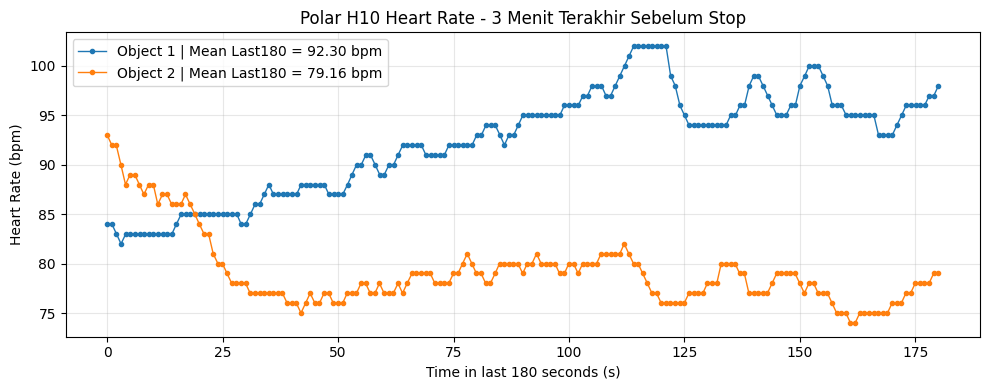

In [9]:
# ============================================================
# 9. GRAFIK HR 3 MENIT TERAKHIR SEBELUM STOP
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    df_obj1_cut["Time_cut_s"], df_obj1_cut["HR_bpm"],
    marker=".", linewidth=1,
    label=f"{NAMA_OBJECT_1} | Mean Last180 = {df_obj1_cut['HR_bpm'].mean():.2f} bpm"
)

plt.plot(
    df_obj2_cut["Time_cut_s"], df_obj2_cut["HR_bpm"],
    marker=".", linewidth=1,
    label=f"{NAMA_OBJECT_2} | Mean Last180 = {df_obj2_cut['HR_bpm'].mean():.2f} bpm"
)

plt.xlabel("Time in last 180 seconds (s)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Polar H10 Heart Rate - 3 Menit Terakhir Sebelum Stop")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


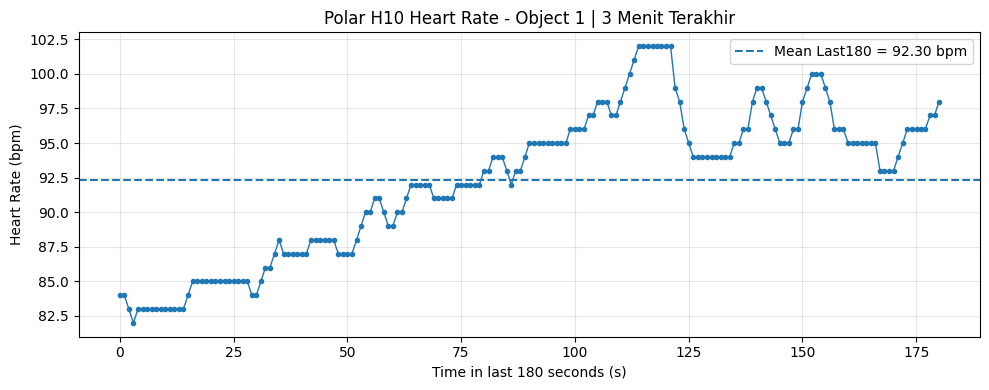

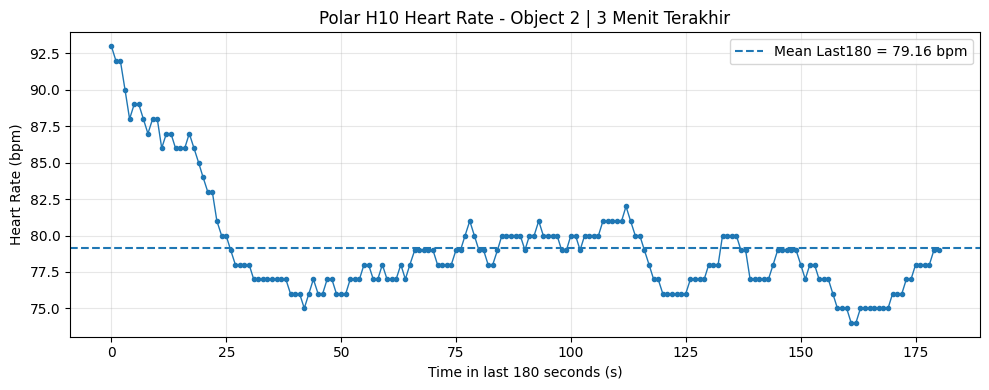

In [10]:
# ============================================================
# 10. GRAFIK HR MASING-MASING OBJECT
# ============================================================

for df_cut, name in [(df_obj1_cut, NAMA_OBJECT_1), (df_obj2_cut, NAMA_OBJECT_2)]:
    plt.figure(figsize=(10, 4))
    plt.plot(df_cut["Time_cut_s"], df_cut["HR_bpm"], marker=".", linewidth=1)
    plt.axhline(
        df_cut["HR_bpm"].mean(),
        linestyle="--",
        label=f"Mean Last180 = {df_cut['HR_bpm'].mean():.2f} bpm"
    )
    plt.xlabel("Time in last 180 seconds (s)")
    plt.ylabel("Heart Rate (bpm)")
    plt.title(f"Polar H10 Heart Rate - {name} | 3 Menit Terakhir")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
# ============================================================
# 11. RINGKASAN UNTUK TABEL GROUND TRUTH
# ============================================================

gt_hr_df = summary_df[[
    "Subject",
    "Cut Timestamp Awal",
    "Cut Timestamp Akhir",
    "Cut Durasi_s",
    "Cut Jumlah Data",
    "HR Mean Last180_bpm",
    "HR Median Last180_bpm",
    "HR Min Last180_bpm",
    "HR Max Last180_bpm",
    "HR Std Last180_bpm"
]].copy()

print("RINGKASAN HR UNTUK GROUND TRUTH")
print("Gunakan kolom HR Mean Last180_bpm sebagai nilai HR Polar H10.")
display(gt_hr_df)

print("\nKalimat ringkas untuk buku TA:")
for _, row in summary_df.iterrows():
    print(
        f"{row['Subject']}: nilai ground truth HR Polar H10 dihitung dari 180 detik terakhir "
        f"sebelum perekaman berhenti, yaitu dari {row['Cut Timestamp Awal']} sampai "
        f"{row['Cut Timestamp Akhir']}. Rata-rata HR yang diperoleh adalah "
        f"{row['HR Mean Last180_bpm']} bpm."
    )


RINGKASAN HR UNTUK GROUND TRUTH
Gunakan kolom HR Mean Last180_bpm sebagai nilai HR Polar H10.


,Subject,Cut Timestamp Awal,Cut Timestamp Akhir,Cut Durasi_s,Cut Jumlah Data,HR Mean Last180_bpm,HR Median Last180_bpm,HR Min Last180_bpm,HR Max Last180_bpm,HR Std Last180_bpm
0,Object 1,2026-05-11T17:53:39.562,2026-05-11T17:56:39.562,180.00,181,92.30,94.0,82,102,5.33
1,Object 2,2026-05-11T17:53:38.067,2026-05-11T17:56:38.042,179.98,181,79.16,78.0,74,93,3.66



Kalimat ringkas untuk buku TA:
Object 1: nilai ground truth HR Polar H10 dihitung dari 180 detik terakhir sebelum perekaman berhenti, yaitu dari 2026-05-11T17:53:39.562 sampai 2026-05-11T17:56:39.562. Rata-rata HR yang diperoleh adalah 92.3 bpm.
Object 2: nilai ground truth HR Polar H10 dihitung dari 180 detik terakhir sebelum perekaman berhenti, yaitu dari 2026-05-11T17:53:38.067 sampai 2026-05-11T17:56:38.042. Rata-rata HR yang diperoleh adalah 79.16 bpm.


## Catatan Metode untuk BAB IV

Kalimat yang bisa digunakan:

> Karena durasi perekaman radar adalah 180 detik, maka data Polar H10 sebagai ground truth dipotong pada durasi yang sama. Pemotongan dilakukan dengan mengambil 180 detik terakhir sebelum perekaman Polar berhenti. Pendekatan ini digunakan karena perekaman Polar dapat berjalan lebih awal sejak perangkat terhubung, sedangkan bagian akhir perekaman dianggap paling sesuai dengan periode pengambilan data radar. Dengan demikian, nilai rata-rata HR Polar H10 yang digunakan sebagai ground truth dihitung dari rentang 180 detik terakhir tersebut.
